In [3]:
import pandas as pd

df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

# Data Cleaning

In [5]:
df_clean = df.copy()

In [6]:
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [7]:
print(df_clean.columns.tolist())


['customerid', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason']


In [8]:
columns_to_drop = [
    "customerid",
    "count",
    "country",
    "state",
    "city",
    "zip_code",
    "lat_long",
    "latitude",
    "longitude"
]

df_clean.drop(columns=columns_to_drop, inplace=True)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis


In [19]:
df_clean['churn_label'].value_counts()

churn_label
No     5174
Yes    1869
Name: count, dtype: int64

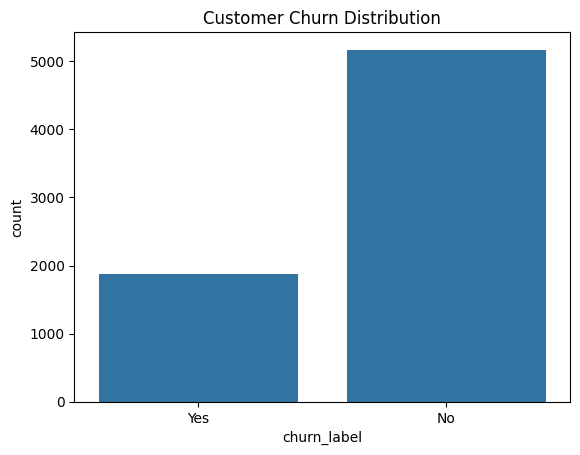

In [20]:
#Visualizing churn distribution
sns.countplot(x='churn_label', data=df_clean)

plt.title("Customer Churn Distribution")

plt.show()

In [21]:
churn_percent = (
    df_clean['churn_label']
    .value_counts(normalize=True) * 100
)

print(churn_percent)

churn_label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


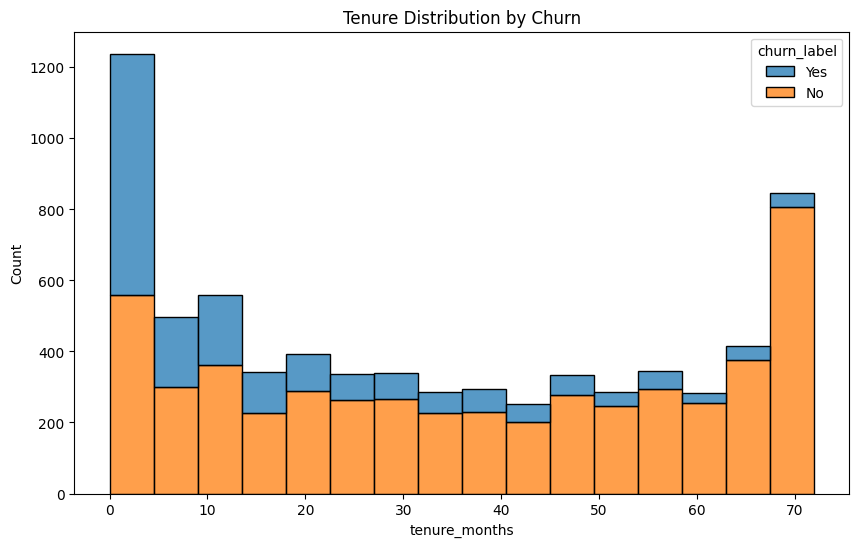

In [22]:
#Tenure vs churn
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean,
    x='tenure_months',
    hue='churn_label',
    multiple='stack'
)

plt.title("Tenure Distribution by Churn")

plt.show()

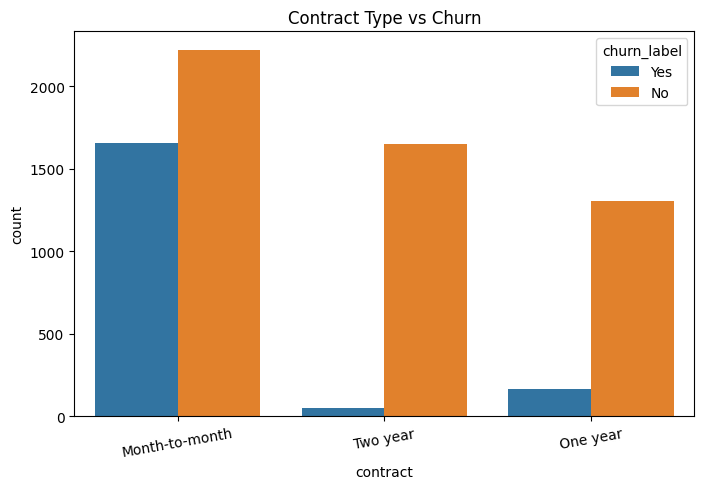

In [23]:
#Contract vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x='contract',
    hue='churn_label',
    data=df_clean
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=10)

plt.show()

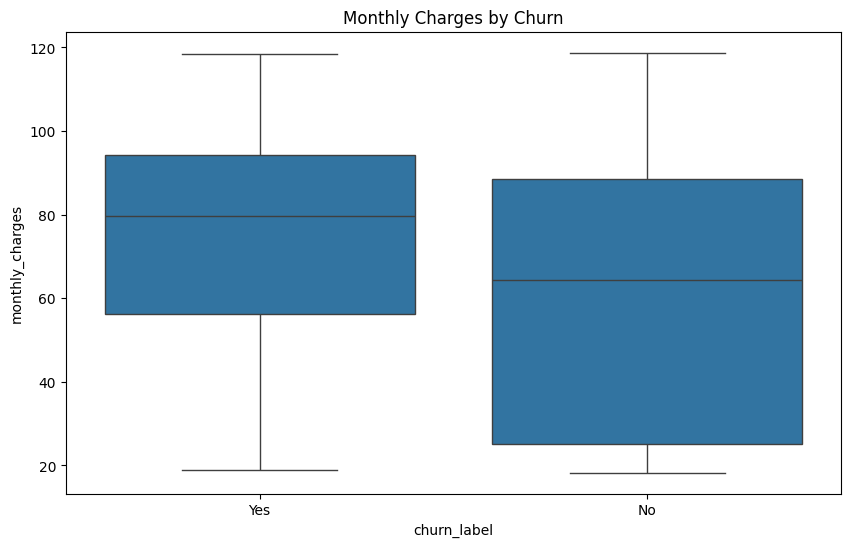

In [24]:
#Monthly Charges vs Churn
plt.figure(figsize=(10,6))

sns.boxplot(
    x='churn_label',
    y='monthly_charges',
    data=df_clean
)

plt.title("Monthly Charges by Churn")

plt.show()

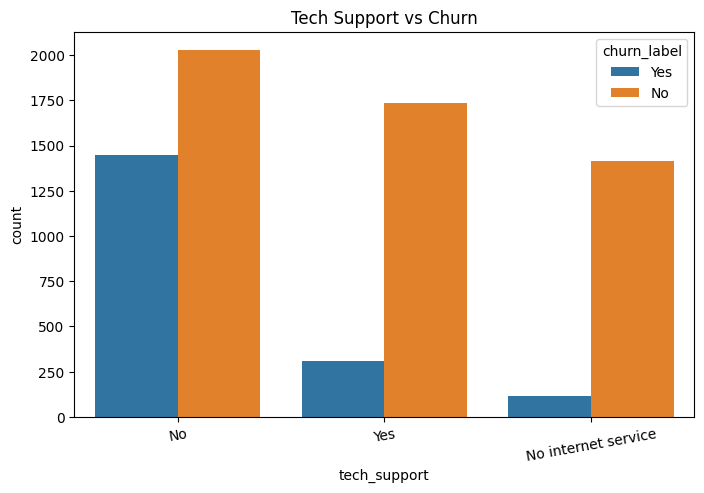

In [25]:
#tech support vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x='tech_support',
    hue='churn_label',
    data=df_clean
)

plt.title("Tech Support vs Churn")

plt.xticks(rotation=10)

plt.show()

CORRELATION AND ML PREPARATION

In [45]:
df_ml = df_clean.copy()

In [46]:
df_ml.drop(columns=['churn_reason'], inplace=True)

In [47]:
df_ml['churn_label'] = df_ml['churn_label'].map({
    'Yes': 1,
    'No': 0
})

In [48]:
df_ml['monthly_charges'] = pd.to_numeric(
    df_ml['monthly_charges'],
    errors='coerce'
)

df_ml['total_charges'] = pd.to_numeric(
    df_ml['total_charges'],
    errors='coerce'
)

df_ml['cltv'] = pd.to_numeric(
    df_ml['cltv'],
    errors='coerce'
)

In [49]:
df_ml[['monthly_charges', 'total_charges', 'cltv']].dtypes

monthly_charges    float64
total_charges      float64
cltv                 int64
dtype: object

In [50]:
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [51]:
df_ml.shape

(7043, 34)

In [ ]:
X = df_ml.drop('churn_label', axis=1) #Customer prediction

y = df_ml['churn_label']  #churn prediction

In [56]:
df_ml.isnull().sum().sort_values(ascending=False)

total_charges                             11
tenure_months                              0
monthly_charges                            0
churn_label                                0
churn_value                                0
churn_score                                0
cltv                                       0
gender_Male                                0
senior_citizen_Yes                         0
partner_Yes                                0
dependents_Yes                             0
phone_service_Yes                          0
multiple_lines_No phone service            0
multiple_lines_Yes                         0
internet_service_Fiber optic               0
internet_service_No                        0
online_security_No internet service        0
online_security_Yes                        0
online_backup_No internet service          0
online_backup_Yes                          0
device_protection_No internet service      0
device_protection_Yes                      0
tech_suppo

In [57]:
df_ml = df_ml.dropna()

In [65]:
df_ml = df_ml.drop(columns=['churn_value', 'churn_score'])

In [66]:
X = df_ml.drop('churn_label', axis=1)

y = df_ml['churn_label']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
y_pred = model.predict(X_test_scaled)

In [70]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8137882018479033


Proper Model Evaluation

In [71]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.64       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.76      1407
weighted avg       0.81      0.81      0.81      1407



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

#Confusion Matrix

[[914  98]
 [164 231]]


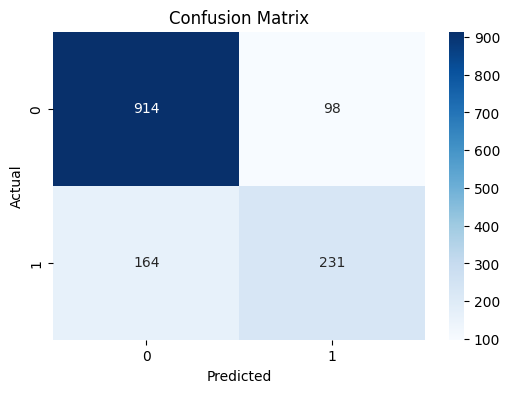

In [73]:
#Visualize Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Which factors influence churn the most?

In [74]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
#Extract Feature Importance

In [75]:
#Sorting Imp Features
feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
2,total_charges,0.720433
11,internet_service_Fiber optic,0.278054
27,paperless_billing_Yes,0.198463
6,partner_Yes,0.156506
29,payment_method_Electronic check,0.126589
1,monthly_charges,0.114002
10,multiple_lines_Yes,0.103356
9,multiple_lines_No phone service,0.086838
24,streaming_movies_Yes,0.072072
5,senior_citizen_Yes,0.048054


In [76]:
feature_importance.tail(10)

,Feature,Coefficient
17,device_protection_No internet service,-0.040085
28,payment_method_Credit card (automatic),-0.073081
16,online_backup_Yes,-0.074699
8,phone_service_Yes,-0.086838
20,tech_support_Yes,-0.158408
14,online_security_Yes,-0.194196
25,contract_One year,-0.265705
26,contract_Two year,-0.596519
7,dependents_Yes,-0.633394
0,tenure_months,-1.484623


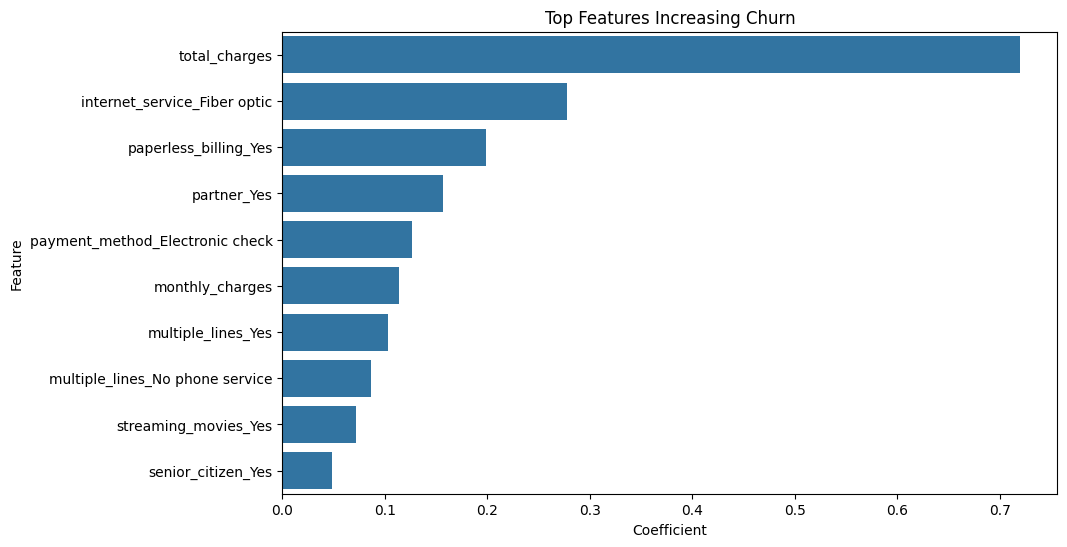

In [77]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title("Top Features Increasing Churn")

plt.show()

In [78]:
df_clean.to_csv("../outputs/cleaned_churn_data.csv", index=False)

In [79]:
df_ml.to_csv("../outputs/ml_ready_churn_data.csv", index=False)
